# EDA — Russian Sentiment Dataset

Exploratory Data Analysis for the unified dataset collected by `DataCollectionAgent`.

**Sections**
1. Load data
2. Dataset overview
3. Class distribution
4. Text length distribution
5. Top-20 words
6. Missing values
7. Source breakdown

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent))

import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = '../data/raw/unified_dataset.csv'

## 1. Collect data (if not already present)

In [2]:
if not Path(DATA_PATH).exists():
    print('Collecting data...')
    from agents.data_collection_agent import DataCollectionAgent
    agent = DataCollectionAgent(config='../config.yaml')
    agent.run()
else:
    print(f'Data already present at {DATA_PATH}')

Data already present at ../data/raw/unified_dataset.csv


## 2. Load & overview

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (2000, 6)
Columns: ['text', 'audio', 'image', 'label', 'source', 'collected_at']


,text,audio,image,label,source,collected_at
0,ÐÐ¾ÑÑÐ´ÐµÐ±Ð½Ð¾Ðµ ÑÐ°ÑÑÐ»ÐµÐ´Ð¾Ð²Ð°Ð½Ð¸Ð...,NaN,NaN,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z
1,ÐÐµÐ´Ð¸ÐºÐ¸ ÑÐ°ÑÑÐºÐ°Ð·Ð°Ð»Ð¸ Ð¾ ÑÐ¾ÑÑÐ...,NaN,NaN,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z
2,"ÐÑÐ¾ÑÐµÐ» Ð¿Ð¾ÑÑÐ¸ Ð³Ð¾Ð´ , ÐºÐ°Ðº Ð¶ÐµÐ»...",NaN,NaN,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z
3,ÐÐ¾ Ð¸ÑÐ¾Ð³Ð°Ð¼ 12 Ð¼ÐµÑÑÑÐµÐ² 2016 Ð³Ð¾Ð...,NaN,NaN,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z
4,ÐÑÑÐ°Ð½Ð° . 21 Ð½Ð¾ÑÐ±ÑÑ . Kazakhstan To...,NaN,NaN,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   text          2000 non-null   str    
 1   audio         0 non-null      float64
 2   image         0 non-null      float64
 3   label         2000 non-null   str    
 4   source        2000 non-null   str    
 5   collected_at  2000 non-null   str    
dtypes: float64(2), str(4)
memory usage: 93.9 KB


## 3. Class distribution

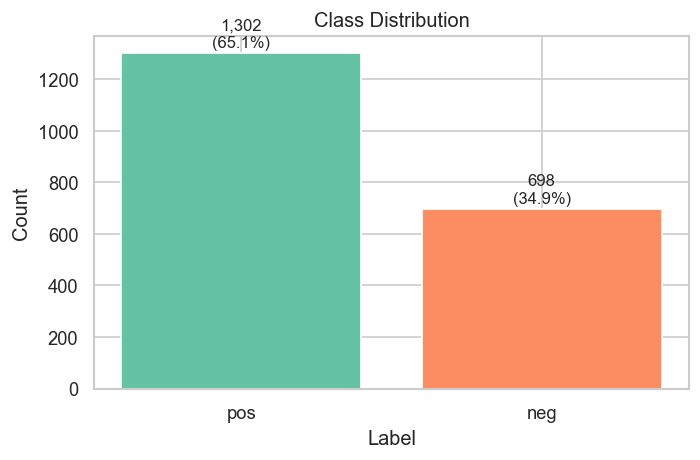

label
pos    1302
neg     698
Name: count, dtype: int64


In [5]:
counts = df['label'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values,
              color=sns.color_palette('Set2', len(counts)))
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f'{val:,}\n({100*val/len(df):.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
plt.tight_layout()
plt.show()

print(counts)

## 4. Text length distribution

In [6]:
df['text_len'] = df['text'].fillna('').str.len()
df['word_count'] = df['text'].fillna('').str.split().str.len()

print(df[['text_len', 'word_count']].describe().round(1))

       text_len  word_count
count    2000.0      2000.0
mean     5137.6       588.6
std     11662.0      1299.0
min        29.0         4.0
25%      1561.5       200.8
50%      2773.0       330.0
75%      4835.0       555.2
max    280353.0     37840.0


/var/folders/1m/twlzmm950ps5wcz0nsl3syhr0000gn/T/ipykernel_86811/1299724085.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='text_len',


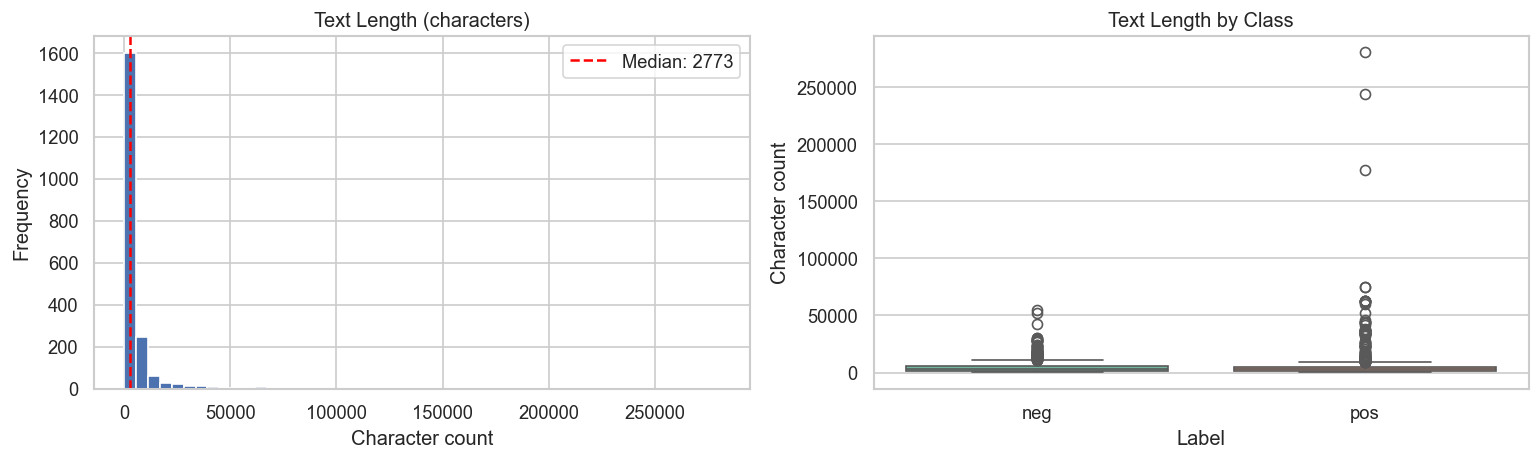

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['text_len'], bins=50, color='#4c72b0', edgecolor='white')
axes[0].axvline(df['text_len'].median(), color='red', linestyle='--',
                label=f"Median: {df['text_len'].median():.0f}")
axes[0].set_xlabel('Character count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Text Length (characters)')
axes[0].legend()

# Per-class boxplot
sns.boxplot(data=df, x='label', y='text_len',
            order=df.groupby('label')['text_len'].median().sort_values().index,
            ax=axes[1], palette='Set2')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Character count')
axes[1].set_title('Text Length by Class')

plt.tight_layout()
plt.show()

## 5. Top-20 words

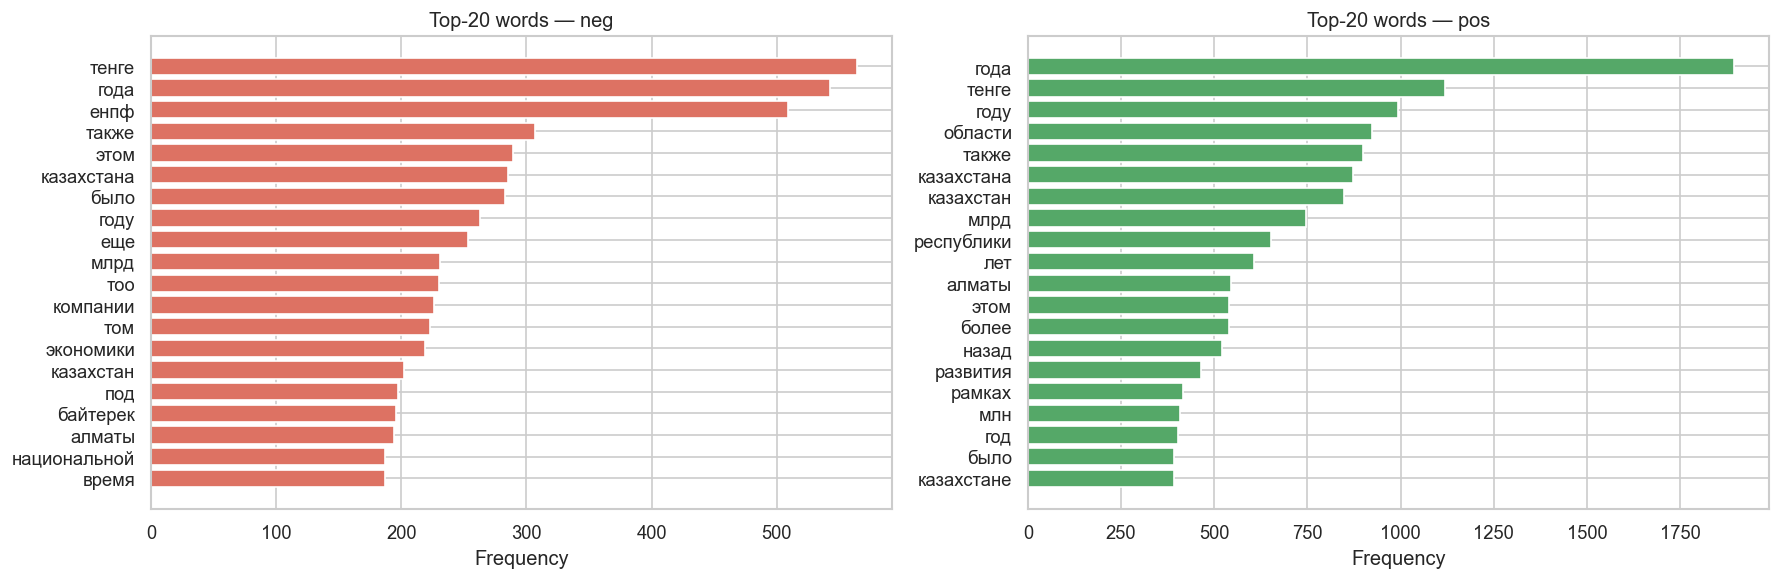

In [8]:
STOPWORDS = {
    'и', 'в', 'не', 'на', 'что', 'с', 'а', 'но', 'как', 'это',
    'по', 'из', 'у', 'да', 'же', 'был', 'его', 'её', 'их', 'за',
    'от', 'так', 'то', 'все', 'он', 'она', 'они', 'мне', 'нет',
    'ещё', 'уже', 'я', 'ты', 'мы', 'вы', 'для', 'при', 'до',
    'или', 'если', 'то', 'этот', 'эта', 'об', 'бы', 'ли', 'ни',
    'к', 'о', 'со', 'во', 'чтобы', 'когда', 'есть', 'быть',
    'был', 'была', 'были', 'будет', 'тоже', 'только', 'можно',
}

def tokenize(text: str) -> list[str]:
    return [w.lower() for w in re.findall(r'[а-яёА-ЯЁ]{3,}', str(text))
            if w.lower() not in STOPWORDS]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, label in zip(axes, ['neg', 'pos']):
    texts = df[df['label'] == label]['text'].fillna('')
    all_words = [w for t in texts for w in tokenize(t)]
    top20 = Counter(all_words).most_common(20)
    words, freqs = zip(*top20)
    ax.barh(words[::-1], freqs[::-1],
            color='#dd7263' if label == 'neg' else '#55a868')
    ax.set_title(f'Top-20 words — {label}')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

## 6. Missing values

              missing      %
text                0    0.0
audio            2000  100.0
image            2000  100.0
label               0    0.0
source              0    0.0
collected_at        0    0.0
text_len            0    0.0
word_count          0    0.0


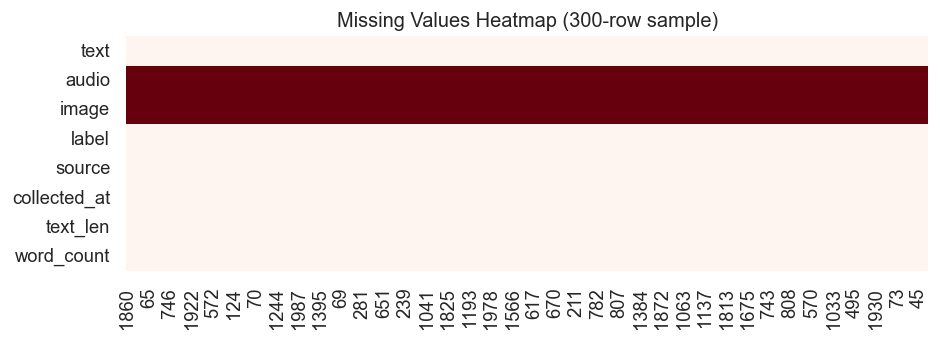

In [9]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(1)
missing = pd.DataFrame({'missing': null_counts, '%': null_pct})
print(missing)

if null_counts.sum() > 0:
    fig, ax = plt.subplots(figsize=(8, 3))
    sns.heatmap(df.isnull().sample(min(300, len(df)), random_state=42).T,
                cbar=False, ax=ax, cmap='Reds', yticklabels=True)
    ax.set_title('Missing Values Heatmap (300-row sample)')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values in text or label columns.')

## 7. Source breakdown

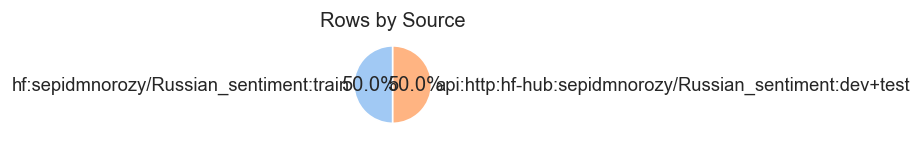

source
hf:sepidmnorozy/Russian_sentiment:train                    1000
api:http:hf-hub:sepidmnorozy/Russian_sentiment:dev+test    1000
Name: count, dtype: int64


In [10]:
src_counts = df['source'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.pie(src_counts.values, labels=src_counts.index,
       autopct='%1.1f%%',
       colors=sns.color_palette('pastel', len(src_counts)),
       startangle=90)
ax.set_title('Rows by Source')
plt.tight_layout()
plt.show()

print(src_counts)

## Summary

In [11]:
summary = {
    'total_rows':    len(df),
    'label_dist':    df['label'].value_counts().to_dict(),
    'sources':       df['source'].value_counts().to_dict(),
    'text_len_mean': round(df['text_len'].mean(), 1),
    'text_len_median': round(df['text_len'].median(), 1),
    'missing_text':  int(df['text'].isnull().sum()),
    'missing_label': int(df['label'].isnull().sum()),
}

for k, v in summary.items():
    print(f'{k:25s}: {v}')

total_rows               : 2000
label_dist               : {'pos': 1302, 'neg': 698}
sources                  : {'hf:sepidmnorozy/Russian_sentiment:train': 1000, 'api:http:hf-hub:sepidmnorozy/Russian_sentiment:dev+test': 1000}
text_len_mean            : 5137.6
text_len_median          : 2773.0
missing_text             : 0
missing_label            : 0
